# ADS1001 Member 4 Notebook  
## Public Risk and Warning Indicators

**Role:** Member 4  
**Project theme:** Identifying useful weather indicators for public communication in Malaysia  
**Notebook section position:** This section is designed to be inserted after Member 3's *Outdoor Comfort Indicators* section and before the final *Overall Recommendations and Limitations* section.

### Member 4 Focus

This notebook analyses weather indicators that are useful for public risk and warning communication:

1. **Rainfall communication:** pressure and precipitation  
2. **Wind-related warning:** wind speed and gust  
3. **UV exposure warning:** UV index and standard UV risk categories  

### Main Project Research Question

**Which weather indicators are most useful for communicating outdoor comfort, rainfall conditions, wind-related risk, and UV exposure to the Malaysian public?**

### Member 4 Research Questions

1. **Is pressure reliable enough to support public rainfall communication, or are precipitation measures more useful?**  
2. **Does gust provide extra warning value beyond average wind speed?**  
3. **How can standard UV index categories support clearer public UV warnings?**

The goal is not only to describe weather variables, but to evaluate whether each indicator is understandable, actionable, and useful for public communication.

### Group Members

- **LI YIMING** — Member 1: Introduction and project framing
- **CHEN ZIMO** — Member 2: Dataset overview and data cleaning
- **HUANG QINGYUE** — Member 3: Outdoor comfort indicators
- **TAY CHEN ZHE** — Member 4: Public risk and warning indicators
- **XU ZIHAO** — Member 5: Overall recommendations and limitations


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Use a relative path so this notebook can be run by other group members
DATA_PATH = Path("malaysia_weather_cleaned_final.csv")

if not DATA_PATH.exists():
    alt_path = Path("data") / "malaysia_weather_cleaned_final.csv"
    if alt_path.exists():
        DATA_PATH = alt_path
    else:
        raise FileNotFoundError(
            "Could not find malaysia_weather_cleaned_final.csv. "
            "Place it in the same folder as this notebook or inside a data/ folder."
        )

weather = pd.read_csv(DATA_PATH)

print("Loaded dataset from:", DATA_PATH)
print("Dataset shape:", weather.shape)
display(weather.head())

Loaded dataset from: malaysia_weather_cleaned_final.csv
Dataset shape: (51693, 38)


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds,temperature_was_imputed,pressure_was_imputed,dew_point_was_imputed,humidity_was_imputed,wind_speed_was_imputed,gust_was_imputed,wind_chill_was_imputed,uv_index_was_imputed,precipitation_rate_was_imputed,precipitation_total_was_imputed,month_number,datetime,temperature_difference,gust_difference,rain_event,pressure_change,falling_pressure,uv_category,high_uv
0,Air Itam,Timur Laut,Pulau Pinang,19.4,1010.33,8.9,50.8,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,17,49,49,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 17:49:49,0.0,0.0,True,NaN,False,Low,False
1,Air Itam,Timur Laut,Pulau Pinang,19.4,1011.01,11.6,60.5,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,19,39,58,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 19:39:58,0.0,0.0,True,0.68,False,Low,False
2,Air Itam,Timur Laut,Pulau Pinang,19.4,1011.51,11.3,59.3,0.0,0.0,19.4,0.0,0.0,34.29,2019,Dec,26,20,29,50,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 20:29:50,0.0,0.0,True,0.50,False,Low,False
3,Air Itam,Timur Laut,Pulau Pinang,19.6,1011.85,12.0,61.3,0.0,0.0,19.6,0.0,0.0,34.29,2019,Dec,26,20,49,50,False,False,False,False,False,False,False,False,False,False,12,2019-12-26 20:49:50,0.0,0.0,True,0.34,False,Low,False
4,Air Itam,Timur Laut,Pulau Pinang,19.3,1012.70,10.4,56.5,0.0,0.0,19.3,0.0,0.0,0.00,2019,Dec,27,0,54,48,False,False,False,False,False,False,False,False,False,False,12,2019-12-27 00:54:48,0.0,0.0,False,0.85,False,Low,False


## 1. Variables Required for Member 4

Member 4 uses the following variables:

| Analysis area | Variables used | Public communication purpose |
|---|---|---|
| Rainfall communication | `pressure`, `precipitation_rate`, `precipitation_total` | Evaluate whether pressure is useful for rainfall messaging |
| Wind warning | `wind_speed`, `gust` | Evaluate whether gust adds warning value beyond average wind speed |
| UV warning | `uv_index`, `hour`, `month` | Use standard UV categories for public warning communication |

If the cleaned dataset already contains engineered variables from Member 2, this notebook uses them. If not, it creates the needed variables again so that this section is reproducible.

In [2]:
# Check required columns
required_cols = [
    "pressure", "precipitation_rate", "precipitation_total",
    "wind_speed", "gust", "uv_index", "hour", "month"
]

missing_required = [col for col in required_cols if col not in weather.columns]
if missing_required:
    raise ValueError(f"Missing required columns for Member 4 analysis: {missing_required}")

# Ensure datetime exists if possible
if "datetime" in weather.columns:
    weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce")
else:
    time_cols = ["year", "month", "day", "hour", "minutes", "seconds"]
    if all(col in weather.columns for col in time_cols):
        weather["datetime"] = pd.to_datetime(weather[time_cols], errors="coerce")
    else:
        weather["datetime"] = pd.NaT

# Create feature engineering variables if not already available
if "rain_event" not in weather.columns:
    weather["rain_event"] = weather["precipitation_total"] > 0

if "gust_difference" not in weather.columns:
    weather["gust_difference"] = weather["gust"] - weather["wind_speed"]

# Pressure change should be calculated within each location if datetime/place are available
if "pressure_change" not in weather.columns:
    sort_cols = []
    if "place" in weather.columns:
        sort_cols.append("place")
    sort_cols.append("datetime")
    if "datetime" in weather.columns and weather["datetime"].notna().any():
        weather = weather.sort_values(sort_cols)
        if "place" in weather.columns:
            weather["pressure_change"] = weather.groupby("place")["pressure"].diff()
        else:
            weather["pressure_change"] = weather["pressure"].diff()
    else:
        weather["pressure_change"] = np.nan

if "falling_pressure" not in weather.columns:
    weather["falling_pressure"] = weather["pressure_change"] < 0

# UV categories
def classify_uv(value):
    if pd.isna(value):
        return np.nan
    if value <= 2:
        return "Low"
    elif value <= 5:
        return "Moderate"
    elif value <= 7:
        return "High"
    elif value <= 10:
        return "Very High"
    else:
        return "Extreme"

if "uv_category" not in weather.columns:
    weather["uv_category"] = weather["uv_index"].apply(classify_uv)

if "high_uv" not in weather.columns:
    weather["high_uv"] = weather["uv_index"] >= 6

member4_cols = [
    "pressure", "precipitation_rate", "precipitation_total", "rain_event",
    "pressure_change", "falling_pressure", "wind_speed", "gust", "gust_difference",
    "uv_index", "uv_category", "high_uv", "hour", "month"
]

print("Member 4 variables prepared:")
display(weather[member4_cols].head())

Member 4 variables prepared:


,pressure,precipitation_rate,precipitation_total,rain_event,pressure_change,falling_pressure,wind_speed,gust,gust_difference,uv_index,uv_category,high_uv,hour,month
0,1010.33,0.0,34.29,True,NaN,False,0.0,0.0,0.0,0.0,Low,False,17,Dec
1,1011.01,0.0,34.29,True,0.68,False,0.0,0.0,0.0,0.0,Low,False,19,Dec
2,1011.51,0.0,34.29,True,0.50,False,0.0,0.0,0.0,0.0,Low,False,20,Dec
3,1011.85,0.0,34.29,True,0.34,False,0.0,0.0,0.0,0.0,Low,False,20,Dec
4,1012.70,0.0,0.00,False,0.85,False,0.0,0.0,0.0,0.0,Low,False,0,Dec


## 2. Data Quality Check for Member 4 Variables

Before analysing public warning indicators, we check whether the required variables are complete in the cleaned dataset.

This matters because variables such as UV index, gust, and precipitation had missing values in the raw dataset. Even if the cleaned dataset contains no missing values, results should still be interpreted carefully because some values may have been imputed during cleaning.

In [3]:
member4_quality = pd.DataFrame({
    "missing_count": weather[member4_cols].isna().sum(),
    "missing_percentage": weather[member4_cols].isna().mean() * 100
}).sort_values("missing_percentage", ascending=False)

display(member4_quality)

# If imputation flag columns exist from Member 2, summarise them
imputation_flags = [
    col for col in weather.columns
    if col.endswith("_was_missing") or col.endswith("_was_imputed")
]
if imputation_flags:
    imputation_summary = pd.DataFrame({
        "imputation_flag": imputation_flags,
        "imputed_count": [weather[col].sum() for col in imputation_flags],
        "imputed_percentage": [weather[col].mean() * 100 for col in imputation_flags]
    }).sort_values("imputed_percentage", ascending=False)
    print("Imputation flag columns detected from Member 2 cleaning:")
    display(imputation_summary)
else:
    print("No imputation flag columns found in this dataset.")

,missing_count,missing_percentage
pressure_change,16,0.030952
pressure,0,0.000000
precipitation_rate,0,0.000000
precipitation_total,0,0.000000
rain_event,0,0.000000
falling_pressure,0,0.000000
wind_speed,0,0.000000
gust,0,0.000000
gust_difference,0,0.000000
uv_index,0,0.000000


Imputation flag columns detected from Member 2 cleaning:


,imputation_flag,imputed_count,imputed_percentage
7,uv_index_was_imputed,12516,24.212176
5,gust_was_imputed,7502,14.512603
8,precipitation_rate_was_imputed,5119,9.902695
9,precipitation_total_was_imputed,5119,9.902695
2,dew_point_was_imputed,4728,9.146306
6,wind_chill_was_imputed,4368,8.449887
0,temperature_was_imputed,4330,8.376376
3,humidity_was_imputed,4323,8.362834
4,wind_speed_was_imputed,2860,5.532664
1,pressure_was_imputed,2408,4.658271


### Short Conclusion: Member 4 Data Quality

The cleaned dataset contains the main variables required for rainfall, wind, and UV warning analysis. If imputation flags are available, later interpretation should pay extra attention to indicators that were heavily imputed, especially UV index, gust, and precipitation-related variables.

## 3. Rainfall Communication: Pressure and Precipitation

### Research Question

**Is pressure reliable enough to support public rainfall communication, or are precipitation measures more useful?**

### Why this matters to the client

A public weather information service may want to use pressure as an early signal of changing weather. However, pressure is not easy for the general public to interpret directly. Rainfall measures such as precipitation rate or precipitation total are more directly actionable.

This section checks whether pressure is strongly related to precipitation and whether falling pressure is useful as supporting context.

In [4]:
rainfall = weather[
    ["pressure", "pressure_change", "falling_pressure", "precipitation_rate", "precipitation_total", "rain_event"]
].dropna(subset=["pressure", "precipitation_total"]).copy()

rainfall_summary = pd.DataFrame({
    "Metric": [
        "Valid rows",
        "Mean pressure",
        "Median pressure",
        "Mean precipitation total",
        "Median precipitation total",
        "Rain event rate",
        "Correlation: pressure vs precipitation total",
        "Correlation: pressure change vs precipitation total"
    ],
    "Value": [
        len(rainfall),
        rainfall["pressure"].mean(),
        rainfall["pressure"].median(),
        rainfall["precipitation_total"].mean(),
        rainfall["precipitation_total"].median(),
        rainfall["rain_event"].mean(),
        rainfall["pressure"].corr(rainfall["precipitation_total"]),
        rainfall[["pressure_change", "precipitation_total"]].dropna()["pressure_change"].corr(
            rainfall[["pressure_change", "precipitation_total"]].dropna()["precipitation_total"]
        )
    ]
})

display(rainfall_summary)

,Metric,Value
0,Valid rows,51693.000000
1,Mean pressure,1010.199369
2,Median pressure,1010.500000
3,Mean precipitation total,2.815153
4,Median precipitation total,0.000000
5,Rain event rate,0.258700
6,Correlation: pressure vs precipitation total,0.046233
7,Correlation: pressure change vs precipitation ...,0.030164


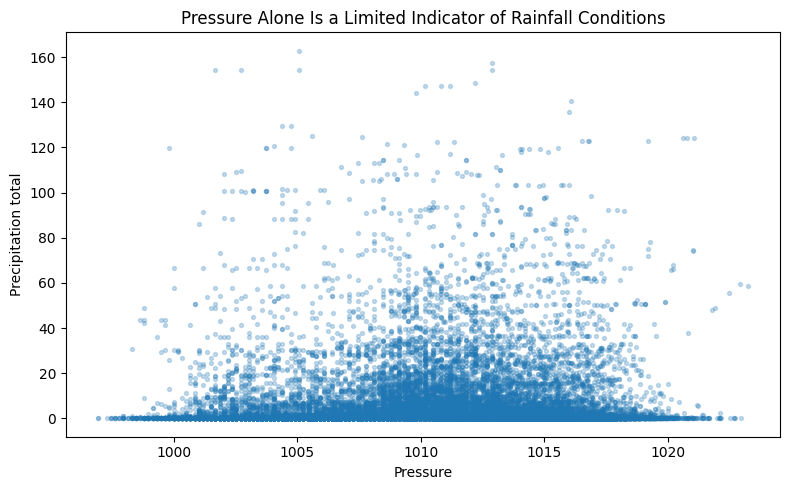

In [5]:
# Pressure vs precipitation visualisation
plt.figure(figsize=(8, 5))
plt.scatter(rainfall["pressure"], rainfall["precipitation_total"], alpha=0.25, s=8)
plt.title("Pressure Alone Is a Limited Indicator of Rainfall Conditions")
plt.xlabel("Pressure")
plt.ylabel("Precipitation total")
plt.tight_layout()
plt.show()

,pressure_group,rain_event,rain_event_percentage
0,"(996.9490000000001, 1007.45]",0.202196,20.219614
1,"(1007.45, 1010.5]",0.270096,27.009598
2,"(1010.5, 1013.24]",0.283249,28.324923
3,"(1013.24, 1023.23]",0.281439,28.143945


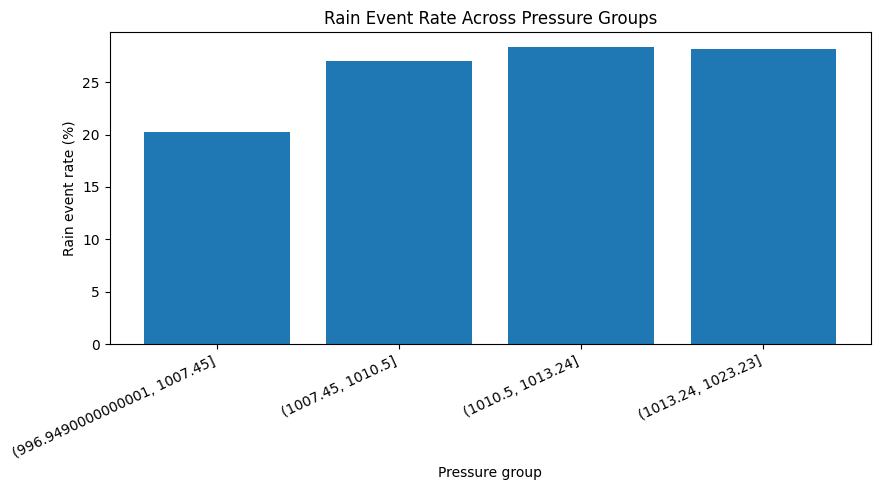

In [6]:
# Rain event rate by pressure quartile
rainfall["pressure_group"] = pd.qcut(rainfall["pressure"], q=4, duplicates="drop")
rain_event_by_pressure = rainfall.groupby("pressure_group", observed=False)["rain_event"].mean().reset_index()
rain_event_by_pressure["rain_event_percentage"] = rain_event_by_pressure["rain_event"] * 100

display(rain_event_by_pressure)

plt.figure(figsize=(9, 5))
plt.bar(rain_event_by_pressure["pressure_group"].astype(str), rain_event_by_pressure["rain_event_percentage"])
plt.title("Rain Event Rate Across Pressure Groups")
plt.xlabel("Pressure group")
plt.ylabel("Rain event rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

,falling_pressure,count,rain_event_rate,rain_event_rate_percentage
0,False,28106,0.274817,27.481677
1,True,23571,0.239532,23.953163


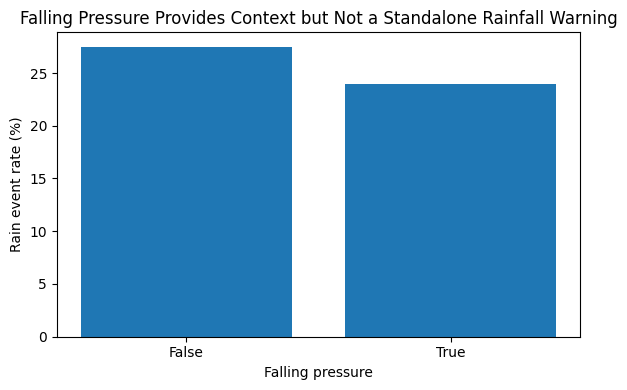

In [7]:
# Falling pressure analysis
falling_pressure_summary = rainfall.dropna(subset=["pressure_change"]).groupby("falling_pressure")["rain_event"].agg(
    count="count",
    rain_event_rate="mean"
).reset_index()

falling_pressure_summary["rain_event_rate_percentage"] = falling_pressure_summary["rain_event_rate"] * 100
display(falling_pressure_summary)

plt.figure(figsize=(6, 4))
plt.bar(
    falling_pressure_summary["falling_pressure"].astype(str),
    falling_pressure_summary["rain_event_rate_percentage"]
)
plt.title("Falling Pressure Provides Context but Not a Standalone Rainfall Warning")
plt.xlabel("Falling pressure")
plt.ylabel("Rain event rate (%)")
plt.tight_layout()
plt.show()

### Interpretation: Pressure and Rainfall

Pressure may provide some background context for rainfall conditions, especially when pressure is changing. However, pressure is not as direct or understandable for the public as precipitation rate or precipitation total.

For public communication, the client should avoid using pressure alone as a rainfall warning. Pressure can be used internally or as supporting context, while precipitation measures should be prioritised for public rainfall alerts.

### Short Conclusion: Pressure and Precipitation

Pressure is useful as a supporting technical indicator, but it is not clear enough to be a standalone public rainfall warning. Precipitation-related measures are more direct, understandable, and actionable for the public.

## 4. Wind-Related Warning: Wind Speed and Gust

### Research Question

**Does gust provide extra warning value beyond average wind speed?**

### Why this matters to the client

Average wind speed describes general wind conditions, but gust captures sudden increases in wind strength. Sudden gusts may affect outdoor users, drivers, commuters, and event organisers.

This section evaluates whether gust should be communicated separately from average wind speed.

In [8]:
wind = weather[["wind_speed", "gust", "gust_difference"]].dropna().copy()

# Define high gust as the 90th percentile of gust values
high_gust_threshold = wind["gust"].quantile(0.90)
wind["high_gust_event"] = wind["gust"] >= high_gust_threshold

wind_summary = pd.DataFrame({
    "Metric": [
        "Valid rows",
        "Mean wind speed",
        "Median wind speed",
        "Mean gust",
        "Median gust",
        "Mean gust difference",
        "Median gust difference",
        "Correlation: wind speed vs gust",
        "High gust threshold (90th percentile)",
        "High gust event rate"
    ],
    "Value": [
        len(wind),
        wind["wind_speed"].mean(),
        wind["wind_speed"].median(),
        wind["gust"].mean(),
        wind["gust"].median(),
        wind["gust_difference"].mean(),
        wind["gust_difference"].median(),
        wind["wind_speed"].corr(wind["gust"]),
        high_gust_threshold,
        wind["high_gust_event"].mean()
    ]
})

display(wind_summary)

,Metric,Value
0,Valid rows,51693.000000
1,Mean wind speed,2.348674
2,Median wind speed,1.000000
3,Mean gust,4.052621
4,Median gust,1.800000
5,Mean gust difference,1.703947
6,Median gust difference,0.500000
7,Correlation: wind speed vs gust,0.600116
8,High gust threshold (90th percentile),9.400000
9,High gust event rate,0.100961


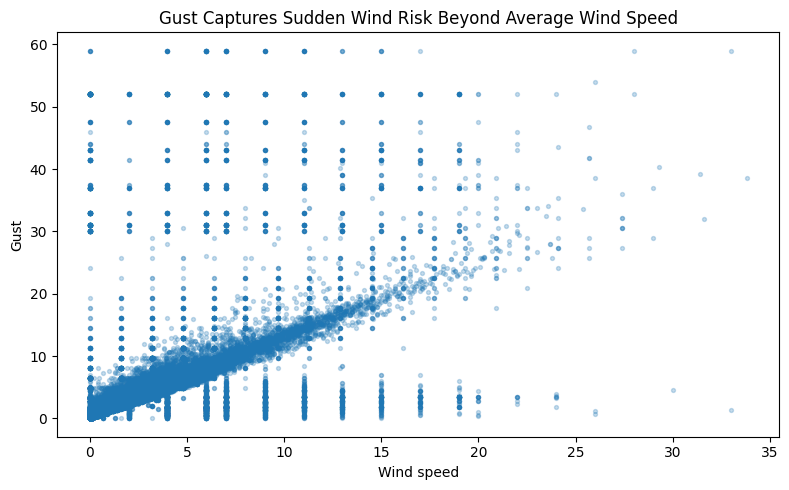

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(wind["wind_speed"], wind["gust"], alpha=0.25, s=8)
plt.title("Gust Captures Sudden Wind Risk Beyond Average Wind Speed")
plt.xlabel("Wind speed")
plt.ylabel("Gust")
plt.tight_layout()
plt.show()

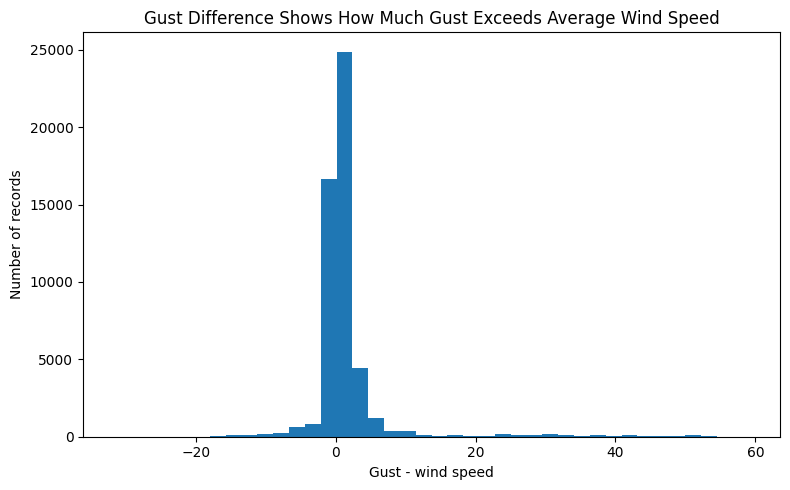

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(wind["gust_difference"], bins=40)
plt.title("Gust Difference Shows How Much Gust Exceeds Average Wind Speed")
plt.xlabel("Gust - wind speed")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

,month,high_gust_event,high_gust_percentage
0,Apr,0.057156,5.715582
1,Aug,0.132171,13.217054
2,Dec,0.126385,12.638469
3,Feb,0.081491,8.149100
4,Jan,0.108084,10.808416
5,Jul,0.104791,10.479099
6,Jun,0.086302,8.630195
7,Mar,0.080382,8.038211
8,May,0.107097,10.709732
9,Nov,0.090088,9.008776


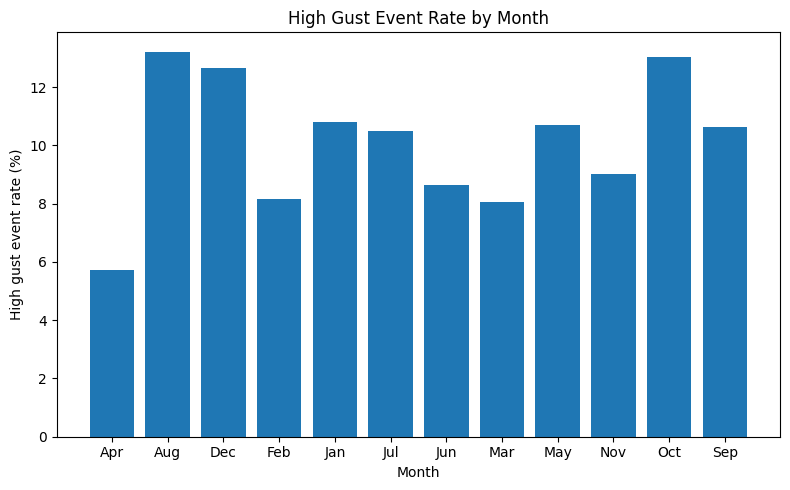

In [11]:
# High gust event rate by month
if "month" in weather.columns:
    wind_with_month = weather[["month", "wind_speed", "gust", "gust_difference"]].dropna().copy()
    threshold = wind_with_month["gust"].quantile(0.90)
    wind_with_month["high_gust_event"] = wind_with_month["gust"] >= threshold
    high_gust_by_month = wind_with_month.groupby("month")["high_gust_event"].mean().reset_index()
    high_gust_by_month["high_gust_percentage"] = high_gust_by_month["high_gust_event"] * 100

    display(high_gust_by_month)

    plt.figure(figsize=(8, 5))
    plt.bar(high_gust_by_month["month"].astype(str), high_gust_by_month["high_gust_percentage"])
    plt.title("High Gust Event Rate by Month")
    plt.xlabel("Month")
    plt.ylabel("High gust event rate (%)")
    plt.tight_layout()
    plt.show()

### Interpretation: Wind Speed and Gust

Wind speed and gust are related, but they do not communicate exactly the same thing. Wind speed describes general wind conditions, while gust captures sudden increases in wind strength.

Even when gust is strongly related to wind speed, it still has public warning value because sudden wind increases may affect outdoor users and transport safety.

### Short Conclusion: Wind Speed and Gust

Wind speed should be used for general wind communication, while gust should be used for sudden wind risk warnings. Gust adds public communication value because it highlights short-term wind increases that average wind speed may not fully capture.

## 5. UV Exposure Warning: UV Index and Public Categories

### Research Question

**How can standard UV index categories support clearer public UV warnings?**

### Why this matters to the client

UV index is highly suitable for public communication because it can be converted into standard risk categories. These categories are easier for the public to understand and can be linked to action advice, such as seeking shade or reducing direct sun exposure.

The standard categories used in this analysis are:

| UV Index | Category |
|---:|---|
| 0–2 | Low |
| 3–5 | Moderate |
| 6–7 | High |
| 8–10 | Very High |
| 11+ | Extreme |

In [12]:
uv = weather[["uv_index", "uv_category", "high_uv", "hour", "month"]].dropna(subset=["uv_index"]).copy()

uv_category_order = ["Low", "Moderate", "High", "Very High", "Extreme"]
uv_category_counts = uv["uv_category"].value_counts().reindex(uv_category_order).fillna(0).astype(int)

uv_summary = pd.DataFrame({
    "Metric": [
        "Valid UV rows",
        "Mean UV index",
        "Median UV index",
        "Maximum UV index",
        "High UV rate (UV >= 6)",
        "Very high or extreme UV rate (UV >= 8)",
        "Extreme UV rate (UV >= 11)"
    ],
    "Value": [
        len(uv),
        uv["uv_index"].mean(),
        uv["uv_index"].median(),
        uv["uv_index"].max(),
        (uv["uv_index"] >= 6).mean(),
        (uv["uv_index"] >= 8).mean(),
        (uv["uv_index"] >= 11).mean()
    ]
})

display(uv_summary)
display(uv_category_counts.to_frame("record_count"))

,Metric,Value
0,Valid UV rows,51693.000000
1,Mean UV index,1.319241
2,Median UV index,0.000000
3,Maximum UV index,16.000000
4,High UV rate (UV >= 6),0.087555
5,Very high or extreme UV rate (UV >= 8),0.039793
6,Extreme UV rate (UV >= 11),0.009653


,record_count
uv_category,
Low,41011
Moderate,6119
High,2506
Very High,1558
Extreme,499


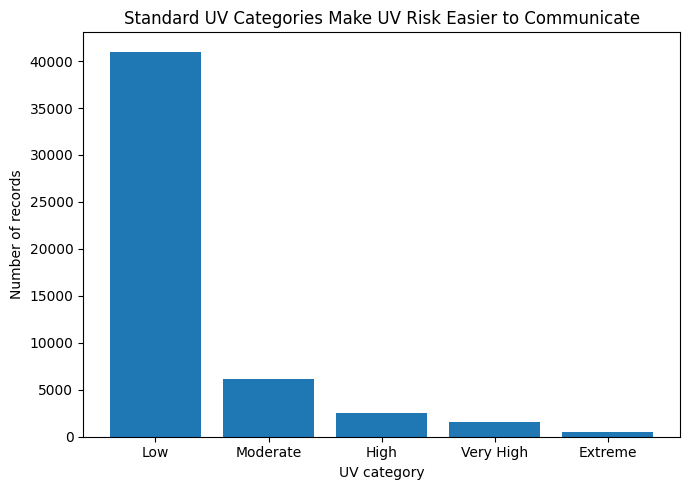

In [13]:
plt.figure(figsize=(7, 5))
plt.bar(uv_category_counts.index, uv_category_counts.values)
plt.title("Standard UV Categories Make UV Risk Easier to Communicate")
plt.xlabel("UV category")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

,hour,uv_index
0,0,0.030636
1,1,0.100812
2,2,0.168741
3,3,0.282342
4,4,0.313039
5,5,0.217227
6,6,0.240553
7,7,0.286501
8,8,0.638838
9,9,1.570291


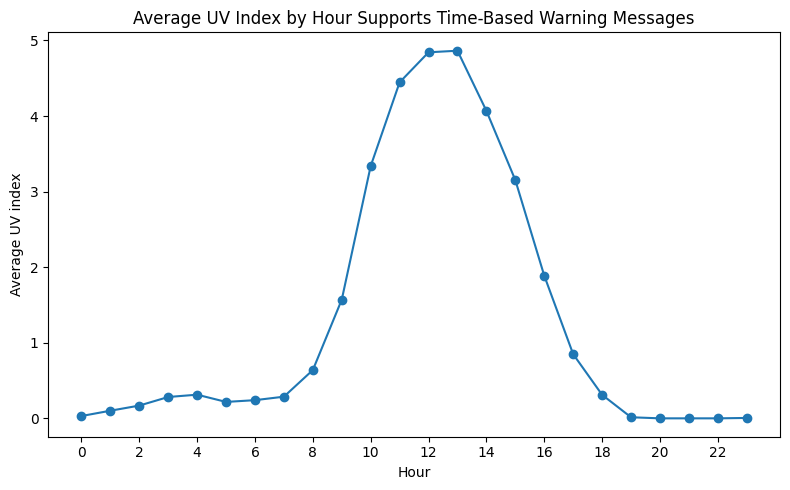

In [14]:
# Average UV index by hour
uv_by_hour = uv.groupby("hour")["uv_index"].mean().reset_index()

display(uv_by_hour)

plt.figure(figsize=(8, 5))
plt.plot(uv_by_hour["hour"], uv_by_hour["uv_index"], marker="o")
plt.title("Average UV Index by Hour Supports Time-Based Warning Messages")
plt.xlabel("Hour")
plt.ylabel("Average UV index")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

,month,high_uv,high_uv_percentage
0,Apr,0.091631,9.163076
1,Aug,0.082558,8.255814
2,Dec,0.070745,7.074522
3,Feb,0.122879,12.287918
4,Jan,0.087708,8.770764
5,Jul,0.070433,7.043329
6,Jun,0.080153,8.015267
7,Mar,0.117195,11.719478
8,May,0.087335,8.733532
9,Nov,0.069179,6.917914


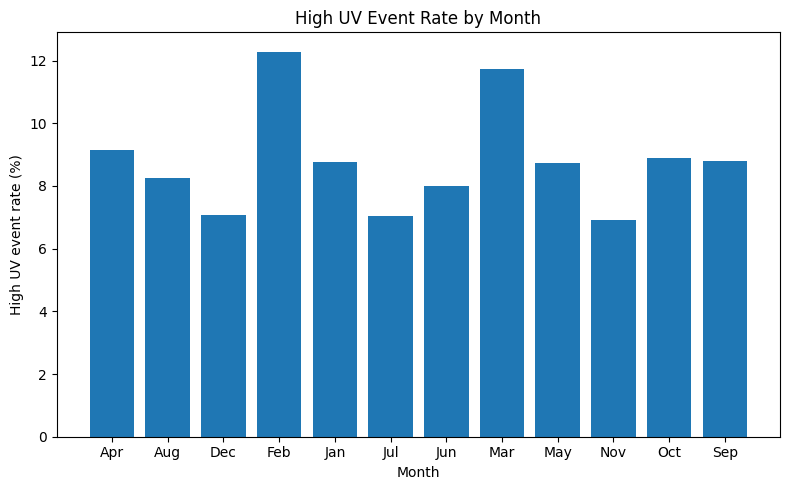

In [15]:
# High UV event rate by month
uv_by_month = uv.groupby("month")["high_uv"].mean().reset_index()
uv_by_month["high_uv_percentage"] = uv_by_month["high_uv"] * 100

display(uv_by_month)

plt.figure(figsize=(8, 5))
plt.bar(uv_by_month["month"].astype(str), uv_by_month["high_uv_percentage"])
plt.title("High UV Event Rate by Month")
plt.xlabel("Month")
plt.ylabel("High UV event rate (%)")
plt.tight_layout()
plt.show()

### Interpretation: UV Index

UV index is one of the strongest public-facing indicators because it already has standard categories. These categories can be translated into clear warnings and action advice.

For example, high, very high, or extreme UV conditions can be communicated with simple messages such as:

- seek shade during high UV periods;
- use sunscreen and protective clothing;
- reduce direct sun exposure during peak UV hours.

### Short Conclusion: UV Index

UV index should be prioritised for public warnings because it is understandable, actionable, and supported by clear risk categories. The client should communicate UV risk using standard categories rather than only reporting raw UV numbers.

## 6. Member 4 Overall Findings

The three analyses support different public communication decisions:

| Indicator area | Main finding | Public communication recommendation |
|---|---|---|
| Pressure and precipitation | Pressure can provide context, but precipitation is clearer for public rainfall communication | Use precipitation for public rainfall alerts; use pressure internally or as support |
| Wind speed and gust | Gust captures sudden wind increases beyond average wind speed | Use wind speed for general conditions and gust for sudden wind warnings |
| UV index | UV index has standard public risk categories | Use UV categories for public warning messages |

These findings will feed into the group’s final recommendation table and conclusion.

In [16]:
member4_recommendations = pd.DataFrame({
    "Indicator": [
        "Precipitation rate / total",
        "Pressure",
        "Wind speed",
        "Gust",
        "UV index"
    ],
    "Public communication value": [
        "High",
        "Low / Medium",
        "High",
        "High",
        "High"
    ],
    "Recommendation": [
        "Use directly for rainfall alerts and outdoor planning messages.",
        "Use internally or as supporting rainfall-risk context, not as a standalone public warning.",
        "Use for general wind condition communication.",
        "Use for sudden wind risk warnings because it captures short-term wind increases.",
        "Use standard UV categories for public warning messages."
    ]
})

display(member4_recommendations)

,Indicator,Public communication value,Recommendation
0,Precipitation rate / total,High,Use directly for rainfall alerts and outdoor p...
1,Pressure,Low / Medium,Use internally or as supporting rainfall-risk ...
2,Wind speed,High,Use for general wind condition communication.
3,Gust,High,Use for sudden wind risk warnings because it c...
4,UV index,High,Use standard UV categories for public warning ...


## 7. Handoff Notes for Group Notebook, Presentation and Poster

### Suggested location in the final group notebook

This section should be placed after:

- Member 2: Data Overview and Data Cleaning  
- Member 3: Outdoor Comfort Indicators  

and before:

- Member 5: Overall Recommendations, Limitations and Future Work  

### Recommended figures for presentation

Use **one or two** of the following in the presentation:

1. **Gust Captures Sudden Wind Risk Beyond Average Wind Speed**  
2. **Standard UV Categories Make UV Risk Easier to Communicate**  
3. **Pressure Alone Is a Limited Indicator of Rainfall Conditions**  

Because the presentation time is short, the wind/gust and UV figures are the strongest choices for public communication.

### Recommended figures for poster

Use:

- **Standard UV Categories Make UV Risk Easier to Communicate**
- **Gust Captures Sudden Wind Risk Beyond Average Wind Speed**

### Final message for Member 5

For risk and warning communication, the client should prioritise **precipitation, gust, wind speed, and UV index**. Pressure may still be useful, but mainly as an internal or supporting indicator rather than a direct public warning.

## 8. Member 4 Final Short Conclusion

This section analysed rainfall, wind-related risk, and UV exposure indicators for public weather communication.

The analysis suggests that **precipitation, gust, wind speed, and UV index** are useful public-facing indicators because they are more understandable or actionable for the public. **Pressure** can provide technical context for rainfall conditions, but it should not be used alone as a public rainfall warning.

For the client, the strongest risk communication indicators are:

1. **Precipitation** for rainfall alerts  
2. **Gust** for sudden wind risk  
3. **Wind speed** for general wind conditions  
4. **UV index** for standard UV warning categories